# Классификация отзывов WB по корневым категориям
**Модель:** `DeepPavlov/rubert-base-cased-sentence`  
**Методы:** Логистическая регрессия · Центроидный классификатор · Сиамская сеть  
**v3:** три файла эмбеддингов + метод-специфичный поиск товаров

---
### Схема файлов и поиска

| Файл | Содержимое | Используется в поиске |
|---|---|---|
| `reviews_embeddings_rubert.h5` | Все отзывы (RuBERT) | Обучение классификаторов |
| `products_raw_rubert.h5` | Все товары (RuBERT, порядок произвольный) | **Метод А** (LogReg) |
| `products_siamese_rubert.h5` | Все товары (через `siamese.encode()`) | **Метод В** (Siamese) |

**Метод Б (Центроиды):** файл на диске не нужен — центроиды уже есть в памяти.  
При поиске сначала находится ближайший центроид (= лучшая категория), затем внутри неё ищутся ближайшие товары из `products_raw_rubert.h5`.  
Это единственный метод, который **автоматически определяет категорию из запроса** вместо того, чтобы просить пользователя её выбрать.

## 0. Установка зависимостей

In [1]:
!pip install -q sentence-transformers scikit-learn sqlalchemy psycopg2-binary pandas numpy matplotlib seaborn torch h5py tqdm

## 1. Импорты и глобальные настройки

In [2]:
import numpy as np
import pandas as pd
import random
import os
import time
import h5py
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from sqlalchemy import create_engine
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

# ── Воспроизводимость ──────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)
print(f"SEED = {SEED}  |  torch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

SEED = 42  |  torch 2.10.0+cpu  |  CUDA: False


## 2. Подключение к PostgreSQL

In [3]:
DB_USER     = 'admin'
DB_PASSWORD = 'admin123'
DB_HOST     = 'localhost'
DB_PORT     = '5433'
DB_NAME     = 'wb_reviews'

engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')
print("Подключение к БД установлено.")

Подключение к БД установлено.


## 3. Загрузка эмбеддинг-модели

In [4]:
MODEL_NAME = 'DeepPavlov/rubert-base-cased-sentence'
print(f"Загрузка модели {MODEL_NAME} ...")
model_st = SentenceTransformer(MODEL_NAME)
print("Модель загружена.")

Загрузка модели DeepPavlov/rubert-base-cased-sentence ...


No sentence-transformers model found with name DeepPavlov/rubert-base-cased-sentence. Creating a new one with mean pooling.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Модель загружена.


## 4. Параметры и пути к файлам кеша

Все три кеш-файла определены здесь, чтобы менять пути в одном месте.

In [5]:
CHUNK_SIZE   = 10_000
TOTAL_LIMIT  = 1_000_000

# ── Файл 1: эмбеддинги всех отзывов (используется для обучения классификаторов) ──
CACHE_REVIEWS  = 'reviews_embeddings_rubert.h5'

# ── Файл 2: эмбеддинги всех товаров от RuBERT, порядок произвольный ─────────────
#    Используется при поиске методом А (LogReg):
#    запрос кодируется «сырым» RuBERT и ищется в этом пространстве.
CACHE_PRODUCTS_RAW  = 'products_raw_rubert.h5'

# ── Файл 3: те же товары, но прогнанные через siamese.encode() ───────────────────
#    Используется при поиске методом В (Siamese):
#    и запрос, и товары переведены в общее метрическое пространство сети.
#    Файл создаётся ПОСЛЕ обучения сиамской сети (секция «Метод В»).
CACHE_PRODUCTS_SIAM = 'products_siamese_rubert.h5'

print("Пути к файлам кеша:")
print(f"  Файл 1 (отзывы):         {CACHE_REVIEWS}")
print(f"  Файл 2 (товары RuBERT):  {CACHE_PRODUCTS_RAW}")
print(f"  Файл 3 (товары Siamese): {CACHE_PRODUCTS_SIAM}")

Пути к файлам кеша:
  Файл 1 (отзывы):         reviews_embeddings_rubert.h5
  Файл 2 (товары RuBERT):  products_raw_rubert.h5
  Файл 3 (товары Siamese): products_siamese_rubert.h5


## 5. Файл 1 — Загрузка и кеширование эмбеддингов отзывов

Если `reviews_embeddings_rubert.h5` уже существует — загружаем из него.  
Иначе — читаем из БД, векторизуем, сохраняем.

In [6]:
if os.path.exists(CACHE_REVIEWS):
    print(f"[Файл 1] Кеш найден: {CACHE_REVIEWS} — загружаю...")
    with h5py.File(CACHE_REVIEWS, 'r') as f:
        X_all     = f['X'][:]                           # float32 (N, dim)
        y_all     = f['y_root'].asstr()[:] # корневые категории
        texts_all = f['texts'].asstr()[:] # исходные тексты
        
    print(f"[Файл 1] Загружено: {len(X_all)} отзывов  |  dim={X_all.shape[1]}")

else:
    print(f"[Файл 1] Кеш не найден — читаю из БД и векторизую...")

    sql_query = f"""
    SELECT r.review_text, p.subj_root_name
    FROM wb_reviews r
    INNER JOIN wb_products p ON r.nm_id = p.nm_id
    WHERE r.review_text IS NOT NULL AND r.review_text <> ''
    GROUP BY r.id, p.subj_root_name
    LIMIT {TOTAL_LIMIT}
    """

    X_vectors, y_root, raw_texts_all = [], [], []
    for chunk in pd.read_sql(sql_query, engine, chunksize=CHUNK_SIZE):
        texts = chunk['review_text'].tolist()
        embs  = model_st.encode(texts, batch_size=32, show_progress_bar=False)
        X_vectors.extend(embs.astype(np.float32))
        y_root.extend(chunk['subj_root_name'].tolist())
        raw_texts_all.extend(texts)
        print(f"  векторизовано: {len(X_vectors)} / {TOTAL_LIMIT}", end='\r')

    X_all     = np.array(X_vectors,   dtype=np.float32)
    y_all     = np.array(y_root)
    texts_all = np.array(raw_texts_all)

    print(f"\n[Файл 1] Векторизация завершена: {len(X_all)} отзывов")
    print(f"[Файл 1] Сохраняю в {CACHE_REVIEWS} ...")
    with h5py.File(CACHE_REVIEWS, 'w') as f:
        f.create_dataset('X',      data=X_all, compression='gzip')
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('y_root', data=np.asarray(y_all,     dtype=object), dtype=dt)
        f.create_dataset('texts',  data=np.asarray(texts_all, dtype=object), dtype=dt)
    print(f"[Файл 1] Сохранён: {CACHE_REVIEWS}")

[Файл 1] Кеш найден: reviews_embeddings_rubert.h5 — загружаю...
[Файл 1] Загружено: 1000000 отзывов  |  dim=768


## 6. Сводка категорий и выбор рабочего набора

In [7]:
cat_counts = pd.Series(y_all).value_counts().reset_index()
cat_counts.columns = ['Категория', 'Количество отзывов']
print("=" * 55)
print("СВОДКА: корневые категории в датасете")
print("=" * 55)
print(cat_counts.to_string(index=False))
print("=" * 55)
print(f"Итого категорий: {len(cat_counts)}  |  Всего отзывов: {len(y_all)}")

СВОДКА: корневые категории в датасете
                               Категория  Количество отзывов
                                  Одежда              386111
                                   Обувь              162724
                                 Красота               83179
                              Аксессуары               57354
                                   Белье               42780
                                 Игрушки               26259
                                     Дом               23488
               Книжная продукция и диски               19346
                      Посуда и инвентарь               18423
                       Спортивная одежда               17530
                      Товары для малышей               16582
                          Головные уборы               15597
                      Одежда для малышей               12493
                     Ювелирные украшения                9785
                    Хозяйственные товары       

In [8]:
# ── Выбор категорий ───────────────────────────────────────────────────────────
# ВАРИАНТ A: укажите категории вручную через запятую (оставьте пустым для Варианта Б)
MANUAL_CATEGORIES = "Одежда, Обувь, Красота, Посуда и инвентарь, Дом"   # пример: "Одежда, Обувь, Электроника"

# ВАРИАНТ Б: минимальное число отзывов для автоматического включения категории
MIN_REVIEWS = 500

if MANUAL_CATEGORIES.strip():
    selected = [c.strip() for c in MANUAL_CATEGORIES.split(',')]
    missing  = [c for c in selected if c not in cat_counts['Категория'].values]
    if missing:
        print(f"   Не найдены в данных: {missing}")
    selected = [c for c in selected if c in cat_counts['Категория'].values]
    print(f"\nВариант А — выбрано вручную ({len(selected)} кат.): {selected}")
else:
    auto_df  = cat_counts[cat_counts['Количество отзывов'] >= MIN_REVIEWS]
    selected = auto_df['Категория'].tolist()
    print(f"\nВариант Б — категории с >= {MIN_REVIEWS} отзывов ({len(selected)} шт.):")
    print(auto_df.to_string(index=False))

if not selected:
    raise ValueError("Нет подходящих категорий — измените параметры выбора.")

mask           = np.isin(y_all, selected)
X_filtered     = X_all[mask]
y_filtered     = y_all[mask]
texts_filtered = texts_all[mask]
print(f"\nПосле фильтрации: {len(X_filtered)} отзывов, {len(np.unique(y_filtered))} категорий.")


Вариант А — выбрано вручную (5 кат.): ['Одежда', 'Обувь', 'Красота', 'Посуда и инвентарь', 'Дом']

После фильтрации: 673925 отзывов, 5 категорий.


## 7. Балансировка классов

In [9]:
MAX_PER_CLASS   = 7000
MIN_PER_CLASS   = 3000
IMBALANCE_RATIO = 5.0

set_seed(SEED)
df_bal = pd.DataFrame({'text_idx': range(len(X_filtered)), 'root': y_filtered})

counts_before = df_bal['root'].value_counts()
ratio = counts_before.max() / counts_before.min()
if ratio > IMBALANCE_RATIO:
    print(f"   Дисбаланс классов обнаружен (max/min = {ratio:.1f}):")
    print(counts_before.to_string())
else:
    print(f"Дисбаланс в норме (max/min = {ratio:.1f}).")

# Шаг 1: догрузка малых классов из БД
small_classes    = counts_before[counts_before < MIN_PER_CLASS * 2].index.tolist()
enlarged_classes = []
if small_classes:
    print(f"\nДогрузка данных для малых классов: {small_classes}")
    placeholders = ', '.join([f"'{c}'" for c in small_classes])
    extra_sql = f"""
        SELECT r.review_text, p.subj_root_name
        FROM wb_reviews r
        INNER JOIN wb_products p ON r.nm_id = p.nm_id
        WHERE p.subj_root_name IN ({placeholders})
          AND r.review_text IS NOT NULL AND r.review_text <> ''
        GROUP BY r.id, p.subj_root_name
    """
    try:
        extra_df = pd.read_sql(extra_sql, engine)
        if len(extra_df) > 0:
            extra_emb      = model_st.encode(extra_df['review_text'].tolist(),
                                             batch_size=32, show_progress_bar=False).astype(np.float32)
            X_filtered     = np.vstack([X_filtered, extra_emb])
            y_filtered     = np.concatenate([y_filtered, extra_df['subj_root_name'].values])
            texts_filtered = np.concatenate([texts_filtered, extra_df['review_text'].values])
            df_bal         = pd.DataFrame({'text_idx': range(len(X_filtered)), 'root': y_filtered})
            enlarged_classes = small_classes
            print(f"  Увеличен размер классов: {enlarged_classes}")
    except Exception as e:
        print(f"Не удалось догрузить данные: {e}")

# Шаг 2: исключение слишком малых классов
counts_now      = df_bal['root'].value_counts()
too_small       = counts_now[counts_now < MIN_PER_CLASS].index.tolist()
removed_classes = []
if too_small:
    df_bal          = df_bal[~df_bal['root'].isin(too_small)]
    removed_classes = too_small
    print(f"  Удалены категории (< {MIN_PER_CLASS} отзывов): {removed_classes}")

# Шаг 3: обрезка слишком больших классов
balanced_indices = []
for cat, grp in df_bal.groupby('root'):
    idx = grp['text_idx'].values
    if len(idx) > MAX_PER_CLASS:
        idx = np.random.choice(idx, MAX_PER_CLASS, replace=False)
    balanced_indices.extend(idx)

balanced_indices = np.array(balanced_indices)
X_bal     = X_filtered[balanced_indices]
y_bal     = y_filtered[balanced_indices]
texts_bal = texts_filtered[balanced_indices]

final_counts = pd.Series(y_bal).value_counts()
print("\nРаспределение классов после балансировки:")
print(final_counts.to_string())
print(f"\nИтого: {len(X_bal)} отзывов, {len(final_counts)} категорий.")
if removed_classes:  print(f"Удалены категории: {removed_classes}")
if enlarged_classes: print(f"Увеличен размер классов: {enlarged_classes}")

   Дисбаланс классов обнаружен (max/min = 21.0):
root
Одежда                386111
Обувь                 162724
Красота                83179
Дом                    23488
Посуда и инвентарь     18423

Распределение классов после балансировки:
Дом                   7000
Красота               7000
Обувь                 7000
Одежда                7000
Посуда и инвентарь    7000

Итого: 35000 отзывов, 5 категорий.


## 8. Разбивка на train / val / test и кодирование меток

In [10]:
set_seed(SEED)

X_train, X_temp, y_train, y_temp, texts_train, texts_temp = train_test_split(
    X_bal, y_bal, texts_bal, test_size=0.30, random_state=SEED, stratify=y_bal
)
X_val, X_test, y_val, y_test, texts_val, texts_test = train_test_split(
    X_temp, y_temp, texts_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

# Гарантия: нет unseen-категорий в val/test
train_cats  = set(y_train)
unseen_val  = set(y_val)  - train_cats
unseen_test = set(y_test) - train_cats
if unseen_val or unseen_test:
    print(f"   Unseen в val: {unseen_val} | в test: {unseen_test} — удаляем.")
    m_v = np.isin(y_val,  list(train_cats)); m_t = np.isin(y_test, list(train_cats))
    X_val,   y_val,   texts_val   = X_val[m_v],   y_val[m_v],   texts_val[m_v]
    X_test,  y_test,  texts_test  = X_test[m_t],  y_test[m_t],  texts_test[m_t]
    assert len(X_val) > 0 and len(X_test) > 0
else:
    print("   Все категории в val/test присутствуют в train.")

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

CLASS_NAMES = le.classes_.tolist()
print(f"\nTrain: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")
print(f"Классы ({len(CLASS_NAMES)}): {CLASS_NAMES}")

   Все категории в val/test присутствуют в train.

Train: 24500  |  Val: 5250  |  Test: 5250
Классы (5): ['Дом', 'Красота', 'Обувь', 'Одежда', 'Посуда и инвентарь']


## 9. Сохранение выборок

In [11]:
def save_split_hdf5(path, X, y_enc, y_str, texts, class_names):
    with h5py.File(path, 'w') as f:
        f.create_dataset('X',       data=X, compression='gzip')
        f.create_dataset('y_enc',   data=y_enc)
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('y_str',   data=np.asarray(y_str,       dtype=object), dtype=dt)
        f.create_dataset('texts',   data=np.asarray(texts,       dtype=object), dtype=dt)
        f.create_dataset('classes', data=np.asarray(class_names, dtype=object), dtype=dt)
    print(f"  Сохранено: {path}  ({len(X)} записей)")

print("Сохранение выборок...")
save_split_hdf5('train_split_rubert.h5', X_train, y_train_enc, y_train, texts_train, CLASS_NAMES)
save_split_hdf5('val_split_rubert.h5',   X_val,   y_val_enc,   y_val,   texts_val,   CLASS_NAMES)
save_split_hdf5('test_split_rubert.h5',  X_test,  y_test_enc,  y_test,  texts_test,  CLASS_NAMES)

Сохранение выборок...
  Сохранено: train_split_rubert.h5  (24500 записей)
  Сохранено: val_split_rubert.h5  (5250 записей)
  Сохранено: test_split_rubert.h5  (5250 записей)


## 10. Файл 2 — Загрузка и кеширование эмбеддингов товаров (RuBERT)

Загружаем все товары из `wb_products` с их средним рейтингом из `wb_reviews`.  
Текст для эмбеддинга = `imt_name + '. ' + description`.  

**Этот файл используется методом А (LogReg) и методом Б (Центроиды)**:  
оба работают в одном пространстве RuBERT, поэтому один и тот же индекс подходит для обоих.

In [12]:
if os.path.exists(CACHE_PRODUCTS_RAW):
    print(f"[Файл 2] Кеш найден: {CACHE_PRODUCTS_RAW} — загружаю...")
    with h5py.File(CACHE_PRODUCTS_RAW, 'r') as f:
        prod_X          = f['X'][:]                                  # (N_prod, dim) float32
        prod_nm_ids     = f['nm_ids'][:]                             # артикулы
        prod_categories = f['categories'].asstr()[:]                 # корневая категория (Unicode)
        prod_ratings    = f['ratings'][:]                            # средний рейтинг
        prod_names      = f['names'].asstr()[:]                      # imt_name
        prod_descs      = f['descriptions'].asstr()[:]               # description
    print(f"[Файл 2] Загружено: {len(prod_X)} товаров  |  dim={prod_X.shape[1]}")

else:
    print(f"[Файл 2] Кеш не найден — загружаю товары из БД...")

    products_sql = """
    SELECT
        p.nm_id,
        p.imt_name,
        p.subj_root_name,
        p.description,
        ROUND(AVG(r.product_valuation), 2) AS avg_rating
    FROM wb_products p
    INNER JOIN wb_reviews r ON p.nm_id = r.nm_id
    WHERE p.description IS NOT NULL
      AND p.description <> ''
      AND p.subj_root_name IS NOT NULL
    GROUP BY p.nm_id, p.imt_name, p.subj_root_name, p.description
    LIMIT 500000
    """
    products_df = pd.read_sql(products_sql, engine)
    products_df['description'] = products_df['description'].fillna('').astype(str)
    products_df['imt_name']    = products_df['imt_name'].fillna('').astype(str)

    # Текст для эмбеддинга: название + описание
    prod_texts = (products_df['imt_name'] + '. ' + products_df['description']).tolist()

    print(f"[Файл 2] Загружено {len(products_df)} товаров — векторизую...")
    prod_X = model_st.encode(prod_texts, batch_size=32, show_progress_bar=True).astype(np.float32)

    prod_nm_ids     = products_df['nm_id'].values
    prod_categories = products_df['subj_root_name'].values
    prod_ratings    = products_df['avg_rating'].fillna(0).astype(np.float32).values
    prod_names      = products_df['imt_name'].values
    prod_descs      = products_df['description'].values

    print(f"[Файл 2] Сохраняю в {CACHE_PRODUCTS_RAW} ...")
    with h5py.File(CACHE_PRODUCTS_RAW, 'w') as f:
        f.create_dataset('X',            data=prod_X, compression='gzip')
        f.create_dataset('nm_ids',       data=prod_nm_ids)
        f.create_dataset('ratings',      data=prod_ratings)
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('categories',   data=np.asarray(prod_categories, dtype=object), dtype=dt)
        f.create_dataset('names',        data=np.asarray(prod_names,      dtype=object), dtype=dt)
        f.create_dataset('descriptions', data=np.asarray(prod_descs,      dtype=object), dtype=dt)
    print(f"[Файл 2] Сохранён: {CACHE_PRODUCTS_RAW}")

print(f"\n[Файл 2] Индекс готов: {prod_X.shape}  (товаров × dim)")

[Файл 2] Кеш найден: products_raw_rubert.h5 — загружаю...
[Файл 2] Загружено: 500000 товаров  |  dim=768

[Файл 2] Индекс готов: (500000, 768)  (товаров × dim)


## 11. Вспомогательные функции

In [13]:
# ── Матрица ошибок ─────────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(max(8, len(class_names)), max(6, len(class_names) - 1)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Предсказано', fontsize=12)
    ax.set_ylabel('Истинное',    fontsize=12)
    ax.set_title(title, fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


# ── Примеры предсказаний ───────────────────────────────────────────────────────
def show_random_predictions(y_true_str, y_pred_enc, le, raw_texts, n=10):
    """# | Текст отзыва | Истинная кат. | Предсказание | ✓?"""
    set_seed(SEED)
    idx        = np.random.choice(len(y_true_str), min(n, len(y_true_str)), replace=False)
    y_pred_str = le.inverse_transform(y_pred_enc)
    TEXT_W, CAT_W = 45, 28
    print(f"{'#':<3} {'Текст отзыва':<{TEXT_W}} {'Истинная кат.':<{CAT_W}} {'Предсказание':<{CAT_W}} {'✓?'}")
    print("-" * (3 + 1 + TEXT_W + 1 + CAT_W + 1 + CAT_W + 1 + 3))
    for i, pos in enumerate(idx):
        snippet  = str(raw_texts[pos])[:TEXT_W].replace('\n', ' ')
        if len(str(raw_texts[pos])) > TEXT_W:
            snippet = snippet[:-1] + '…'
        true_lbl = y_true_str[pos]
        pred_lbl = y_pred_str[pos]
        ok       = "yes" if true_lbl == pred_lbl else "no"
        print(f"{i+1:<3} {snippet:<{TEXT_W}} {true_lbl:<{CAT_W}} {pred_lbl:<{CAT_W}} {ok}")


# ── F1 ────────────────────────────────────────────────────────────────────────
def evaluate_f1(y_true_enc, y_pred_enc, average='weighted'):
    return f1_score(y_true_enc, y_pred_enc, average=average)


# ── Поиск ближайших товаров ────────────────────────────────────────────────────
def search_products(query_emb: np.ndarray,
                    category_filter: str,
                    index_X: np.ndarray,
                    nm_ids, categories, ratings, names, descs,
                    top_k: int = 10):
    """
    Ищет top_k товаров ближайших к query_emb по косинусному сходству.

    Параметры
    ---------
    query_emb       : вектор запроса (1-D, уже в нужном пространстве)
    category_filter : название категории или 'все'
    index_X         : матрица товарных эмбеддингов (N, dim)
    nm_ids, ...     : метаданные товаров

    Возвращает
    ----------
    (DataFrame с результатами, время_поиска_в_секундах)
    Время измеряется только для операции cosine_similarity + argsort,
    без учёта кодирования запроса.
    """
    # Фильтр по категории: берём только нужные индексы
    if category_filter.strip().lower() == 'все':
        idx_pool = np.arange(len(index_X))
    else:
        idx_pool = np.where(categories == category_filter)[0]

    if len(idx_pool) == 0:
        return pd.DataFrame(), 0.0

    # Поиск — только это время измеряем
    t0      = time.perf_counter()
    sims    = cosine_similarity(query_emb.reshape(1, -1), index_X[idx_pool])[0]
    top     = np.argsort(sims)[::-1][:top_k]
    elapsed = time.perf_counter() - t0

    real_idx = idx_pool[top]
    results  = pd.DataFrame({
        'Артикул (nm_id)': nm_ids[real_idx],
        'Название':        names[real_idx],
        'Рейтинг':         ratings[real_idx],
        'Сходство':        sims[top].round(4),
        'Описание':        descs[real_idx],
    })
    return results, elapsed


# ── Вывод результатов поиска ───────────────────────────────────────────────────
def print_search_results(results: pd.DataFrame, elapsed: float, category_used: str = ''):
    cat_info = f"  Категория поиска: {category_used}" if category_used else ''
    print(f"\n  Время поиска по эмбеддингам: {elapsed*1000:.1f} мс"
          f"  |  Найдено: {len(results)} товаров{cat_info}")
    print("  " + "─" * 90)
    for rank, (_, row) in enumerate(results.iterrows(), 1):
        desc_snippet = str(row['Описание'])[:120].replace('\n', ' ')
        if len(str(row['Описание'])) > 120:
            desc_snippet += '…'
        print(f"  {rank:>2}. [{row['Артикул (nm_id)']}] {row['Название']}")
        print(f"      Рейтинг: {row['Рейтинг']:.2f} ★  |  Сходство: {row['Сходство']:.4f}")
        print(f"      {desc_snippet}")
        print()


# ── Сохранение лога поиска ─────────────────────────────────────────────────────
def save_search_log(log: list, path: str):
    if not log:
        return
    with h5py.File(path, 'w') as f:
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('queries',    data=np.asarray([d['query']    for d in log], dtype=object), dtype=dt)
        f.create_dataset('categories', data=np.asarray([d['category'] for d in log], dtype=object), dtype=dt)
        f.create_dataset('elapsed_ms', data=np.array([d['elapsed_ms'] for d in log]))
    print(f"  Лог поиска сохранён: {path}  ({len(log)} запросов)")


print("Вспомогательные функции определены.")

Вспомогательные функции определены.


---
## Метод А: Логистическая регрессия

**Классификация:** эмбеддинги отзывов (RuBERT) → признаки для LR.  
**Поиск:** запрос кодируется тем же RuBERT → поиск в **Файле 2** (`products_raw_rubert.h5`).  
Пространство запроса и товаров совпадают — прямое сравнение без дополнительных преобразований.

In [14]:
set_seed(SEED)

print("[A] Обучение логистической регрессии...")
clf_lr = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=SEED)
clf_lr.fit(X_train, y_train_enc)

lr_val_pred  = clf_lr.predict(X_val)
lr_test_pred = clf_lr.predict(X_test)

lr_f1_val  = evaluate_f1(y_val_enc,  lr_val_pred)
lr_f1_test = evaluate_f1(y_test_enc, lr_test_pred)

print(f"F1 (weighted) на val:  {lr_f1_val:.4f}")
print(f"F1 (weighted) на test: {lr_f1_test:.4f}")

[A] Обучение логистической регрессии...
F1 (weighted) на val:  0.8173
F1 (weighted) на test: 0.8149


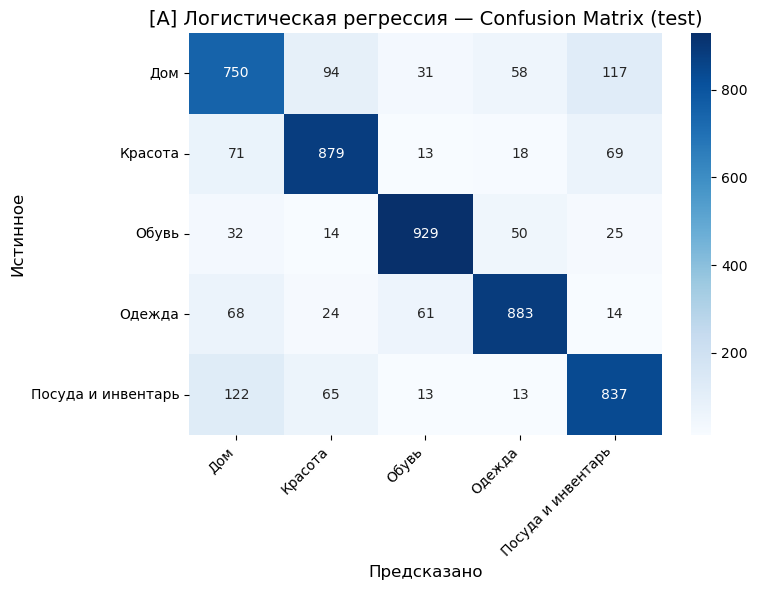

In [15]:
plot_confusion_matrix(y_test_enc, lr_test_pred, CLASS_NAMES,
                      title="[A] Логистическая регрессия — Confusion Matrix (test)")

In [16]:
print("\n[A] 10 случайных примеров предсказаний (тест):")
show_random_predictions(y_test, lr_test_pred, le, texts_test, n=10)


[A] 10 случайных примеров предсказаний (тест):
#   Текст отзыва                                  Истинная кат.                Предсказание                 ✓?
---------------------------------------------------------------------------------------------------------------
1   Лоферы очень красивые и качественно сделаны,… Обувь                        Обувь                        yes
2   Отличное платье, трикотаж мягкий, не просвеч… Одежда                       Одежда                       yes
3   Крем супер, круглогодично пользуюсь только и… Красота                      Красота                      yes
4   Пришёл целый, это главное.Брал для офиса,кол… Дом                          Посуда и инвентарь           no
5   У дочери кудрявые волосы, после шампуня было… Красота                      Красота                      yes
6   Это не спрей. Внутри густая кремообразная ма… Красота                      Красота                      yes
7   Отличные сапоги, мне и нужны были не сильно … Обувь   

### Диалог классификации — Метод А

In [23]:
dialog_log_lr = []

print("=" * 60)
print("[A] Диалог: классификация текста (LogReg)")
print("Введите 'стоп' для выхода.")
print(f"Доступные категории: {CLASS_NAMES}")
print("=" * 60)

while True:
    user_input = input("Текст отзыва: ").strip()
    if user_input.lower() in ('стоп', 'stop', 'quit', 'exit', ''):
        break
    emb      = model_st.encode([user_input])
    pred_enc = clf_lr.predict(emb)[0]
    pred_lbl = le.inverse_transform([pred_enc])[0]
    prob     = clf_lr.predict_proba(emb)[0].max()
    print(f"  → Категория: {pred_lbl}  (уверенность: {prob:.2%})\n")
    dialog_log_lr.append({'text': user_input, 'predicted': pred_lbl, 'prob': float(prob)})

if dialog_log_lr:
    with h5py.File('dialog_logreg_rubert.h5', 'w') as f:
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('texts',       data=np.asarray([d['text']      for d in dialog_log_lr], dtype=object), dtype=dt)
        f.create_dataset('predictions', data=np.asarray([d['predicted'] for d in dialog_log_lr], dtype=object), dtype=dt)
        f.create_dataset('probs',       data=np.array([d['prob']        for d in dialog_log_lr]))
    print(f"Диалог сохранён: dialog_logreg_rubert.h5  ({len(dialog_log_lr)} запросов)")

[A] Диалог: классификация текста (LogReg)
Введите 'стоп' для выхода.
Доступные категории: ['Дом', 'Красота', 'Обувь', 'Одежда', 'Посуда и инвентарь']


Текст отзыва:  отличные кроссовки для бега в сеточку на высокой подошве, качеством доволен, пришли быстро, спасибо


  → Категория: Обувь  (уверенность: 99.91%)



Текст отзыва:  для неспешных прогулок подойдут, на ногу сели хорошо качество чувствуется, швы прочные


  → Категория: Обувь  (уверенность: 99.49%)



...

  → Категория: Дом  (уверенность: 44.43%)



Текст отзыва:  очень красивое платье до колен, приятная ткань


  → Категория: Одежда  (уверенность: 99.97%)



Текст отзыва:  exit


Диалог сохранён: dialog_logreg_rubert.h5  (4 запросов)


### Поиск товаров — Метод А (LogReg)

**Индекс:** `products_raw_rubert.h5` (Файл 2) — RuBERT-эмбеддинги товаров.  
**Запрос:** кодируется тем же RuBERT → прямое косинусное сравнение с индексом.  
**Категория:** задаётся вручную (или `все`). LR-классификатор здесь не используется для поиска — он только обучен разделять пространство; сам поиск — по косинусному сходству эмбеддингов.

In [26]:
search_log_lr = []
categories_str = ', '.join(CLASS_NAMES)

print("=" * 70)
print("[A] Поиск товаров по запросу  (индекс: products_raw_rubert.h5)")
print(f"Доступные категории: {categories_str}")
print("Введите 'стоп' в любом поле для выхода.")
print("=" * 70)

while True:
    query = input("\nЗапрос товара: ").strip()
    if query.lower() in ('стоп', 'stop', 'exit', 'quit', ''):
        break

    print(f"  Доступные категории: {categories_str}")
    print("  (или введите 'все' для поиска по всем категориям)")
    cat_input = input("  Категория: ").strip()
    if cat_input.lower() in ('стоп', 'stop', 'exit', 'quit'):
        break
    if cat_input.lower() != 'все' and cat_input not in CLASS_NAMES:
        print(f"  Категория '{cat_input}' не найдена. Доступны: {categories_str}")
        continue

    # Кодируем запрос «сырым» RuBERT — тем же, что использовался для товаров в Файле 2
    query_emb = model_st.encode([query]).astype(np.float32)[0]

    results, elapsed = search_products(
        query_emb, cat_input,
        prod_X,       # Файл 2: RuBERT-эмбеддинги
        prod_nm_ids, prod_categories, prod_ratings, prod_names, prod_descs
    )
    if results.empty:
        print(f"  Нет товаров в категории '{cat_input}'.")
        continue

    print_search_results(results, elapsed, cat_input)
    search_log_lr.append({'query': query, 'category': cat_input, 'elapsed_ms': elapsed * 1000})

save_search_log(search_log_lr, 'search_log_logreg_rubert.h5')

[A] Поиск товаров по запросу  (индекс: products_raw_rubert.h5)
Доступные категории: Дом, Красота, Обувь, Одежда, Посуда и инвентарь
Введите 'стоп' в любом поле для выхода.



Запрос товара:  кроссовки для бега в сеточку на высокой подошве качественные


  Доступные категории: Дом, Красота, Обувь, Одежда, Посуда и инвентарь
  (или введите 'все' для поиска по всем категориям)


  Категория:  Обувь



  Время поиска по эмбеддингам: 370.1 мс  |  Найдено: 10 товаров  Категория поиска: Обувь
  ──────────────────────────────────────────────────────────────────────────────────────────
   1. [1391831] Кроссовки
      Рейтинг: 4.33 ★  |  Сходство: 0.9285
      Высокие кроссовки, верх которых выполнен из практичного материала. Модель на удобной подошве снабжена шнуровкой. Отличны…

   2. [3642998] Кеды
      Рейтинг: 3.70 ★  |  Сходство: 0.9214
      Яркие комфортные ботинки выполнены из современных материалов. Высокая гибкая подошва с рифлением обеспечивает оптимальны…

   3. [1609020] Кроссовки
      Рейтинг: 4.40 ★  |  Сходство: 0.9167
      Отличные кроссовки на утолщенной рифленой подошве. Мягкая подкладка обеспечит комфорт. Изделие дополнено шнуровкой, кото…

   4. [609370] Кроссовки
      Рейтинг: 5.00 ★  |  Сходство: 0.9113
      Замечательные кроссовки от культового бренда. Модель оформлена контрастными вставками в фирменном стиле Adidas. Рифленая…

   5. [793343] Кроссовки
      

...

  Доступные категории: Дом, Красота, Обувь, Одежда, Посуда и инвентарь
  (или введите 'все' для поиска по всем категориям)


  Категория:  все



  Время поиска по эмбеддингам: 1716.3 мс  |  Найдено: 10 товаров  Категория поиска: все
  ──────────────────────────────────────────────────────────────────────────────────────────
   1. [7120337] Платье
      Рейтинг: 4.22 ★  |  Сходство: 0.9144
      Пояс -в комплект не входит!

   2. [5499861] Платья
      Рейтинг: 3.33 ★  |  Сходство: 0.9106
      ПЛАТЬЕ ЖЕНСКОЕ, пояс в комплект не входит

   3. [8110254] Кардиган
      Рейтинг: 3.57 ★  |  Сходство: 0.9036
      Пояс в комплекте не идет!

   4. [4964936] Платье
      Рейтинг: 3.00 ★  |  Сходство: 0.9034
      В комплектацию пояс не входит.

   5. [6735409] Платье
      Рейтинг: 3.00 ★  |  Сходство: 0.9028
      пояс в комплектацию не входит

   6. [6673148] Пинетки
      Рейтинг: 3.00 ★  |  Сходство: 0.8993
      На носочках антискользящее и непромокаемое покрытие.

   7. [6667263] Пинетки
      Рейтинг: 4.00 ★  |  Сходство: 0.8993
      На носочках антискользящее и непромокаемое покрытие.

   8. [8168606] Брюки
      Рейтинг: 1.0


Запрос товара:  exit


  Лог поиска сохранён: search_log_logreg_rubert.h5  (15 запросов)


---
## Метод Б: Центроидный классификатор

**Классификация:** ближайший центроид по cosine similarity.  
**Поиск:** двухэтапный, использует **Файл 2** (`products_raw_rubert.h5`):  
1. Запрос → сравнение с `centroid_matrix` → автоматически определяется лучшая категория.  
2. Внутри найденной категории ищутся ближайшие товары по косинусному сходству.  

Это единственный метод, который **не просит пользователя выбирать категорию** — центроид определяет её сам.

In [18]:
# Вычисляем центроиды: среднее эмбеддингов всех отзывов каждого класса
centroids = {}
for cls_int in np.unique(y_train_enc):
    mask = y_train_enc == cls_int
    centroids[cls_int] = X_train[mask].mean(axis=0)

# centroid_matrix[i] = эталонный вектор i-го класса
centroid_matrix = np.array([centroids[i] for i in sorted(centroids)], dtype=np.float32)
print(f"[Б] Центроиды вычислены: {centroid_matrix.shape}")

def centroid_predict(X, centroid_matrix):
    sims = cosine_similarity(X, centroid_matrix)
    return np.argmax(sims, axis=1)

cent_val_pred  = centroid_predict(X_val,  centroid_matrix)
cent_test_pred = centroid_predict(X_test, centroid_matrix)

cent_f1_val  = evaluate_f1(y_val_enc,  cent_val_pred)
cent_f1_test = evaluate_f1(y_test_enc, cent_test_pred)
print(f"F1 (weighted) на val:  {cent_f1_val:.4f}")
print(f"F1 (weighted) на test: {cent_f1_test:.4f}")

[Б] Центроиды вычислены: (5, 768)
F1 (weighted) на val:  0.5622
F1 (weighted) на test: 0.5652


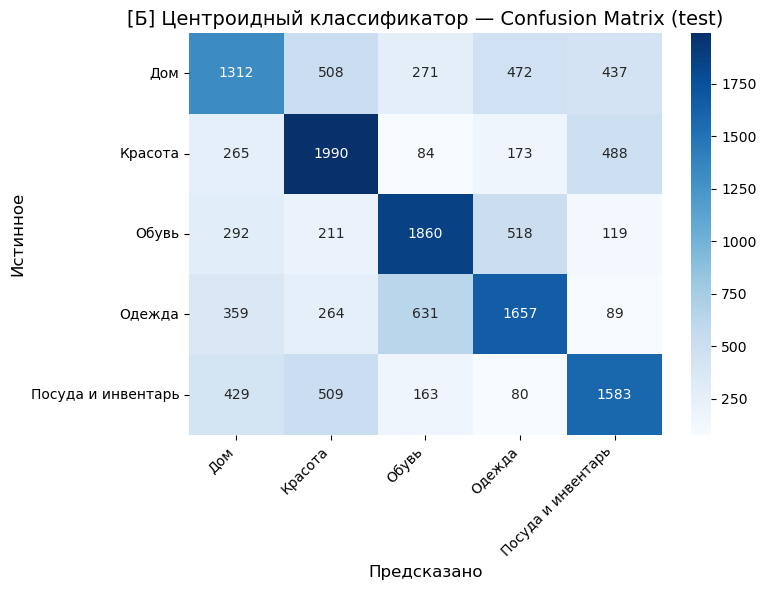

In [16]:
plot_confusion_matrix(y_test_enc, cent_test_pred, CLASS_NAMES,
                      title="[Б] Центроидный классификатор — Confusion Matrix (test)")

In [39]:
print("\n[Б] 10 случайных примеров предсказаний (тест):")
show_random_predictions(y_test, cent_test_pred, le, texts_test, n=10)


[Б] 10 случайных примеров предсказаний (тест):
#   Текст отзыва                                  Истинная кат.                Предсказание                 ✓?
---------------------------------------------------------------------------------------------------------------
1   Во время эксплуатации,насколько я аккуратно … Белье                        Обувь                        no
2   Маска пришла не такая как предлагает продаве… Аксессуары                   Белье                        no
3   Проносила почти все лето, очень универсальны… Обувь                        Красота                      no
4   Та же проблема, вместо заказанного средства,… Красота                      Аксессуары                   no
5   Обычно подходит 38р.р. этого производителя; … Белье                        Аксессуары                   no
6   У мужа ОТ 100 см, ОБ 104 см. Обычно всегда б… Белье                        Обувь                        no
7   Заказ получила! За два дня в Ростовскую обл.… Белье        

### Диалог классификации — Метод Б

In [27]:
dialog_log_cent = []

print("=" * 60)
print("[Б] Диалог: классификация текста (Центроиды)")
print("Введите 'стоп' для выхода.")
print(f"Доступные категории: {CLASS_NAMES}")
print("=" * 60)

while True:
    user_input = input("Текст отзыва: ").strip()
    if user_input.lower() in ('стоп', 'stop', 'quit', 'exit', ''):
        break
    emb      = model_st.encode([user_input]).astype(np.float32)
    sims     = cosine_similarity(emb, centroid_matrix)[0]
    pred_enc = int(np.argmax(sims))
    pred_lbl = le.inverse_transform([pred_enc])[0]
    conf     = float(sims[pred_enc])
    print(f"  → Категория: {pred_lbl}  (cosine sim: {conf:.4f})\n")
    dialog_log_cent.append({'text': user_input, 'predicted': pred_lbl, 'similarity': conf})

if dialog_log_cent:
    with h5py.File('dialog_centroid_rubert.h5', 'w') as f:
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('texts',        data=np.asarray([d['text']       for d in dialog_log_cent], dtype=object), dtype=dt)
        f.create_dataset('predictions',  data=np.asarray([d['predicted']  for d in dialog_log_cent], dtype=object), dtype=dt)
        f.create_dataset('similarities', data=np.array([d['similarity']   for d in dialog_log_cent]))
    print(f"Диалог сохранён: dialog_centroid_rubert.h5  ({len(dialog_log_cent)} запросов)")

[Б] Диалог: классификация текста (Центроиды)
Введите 'стоп' для выхода.
Доступные категории: ['Дом', 'Красота', 'Обувь', 'Одежда', 'Посуда и инвентарь']


Текст отзыва:  кроссовки для бега в сеточку на высокой подошве качественные


  → Категория: Обувь  (cosine sim: 0.7306)



Текст отзыва:  exit


Диалог сохранён: dialog_centroid_rubert.h5  (1 запросов)


### Поиск товаров — Метод Б (Центроиды)

**Индекс:** `products_raw_rubert.h5` (Файл 2) — RuBERT-эмбеддинги товаров.  
**Шаг 1 — автовыбор категории:** запрос сравнивается с `centroid_matrix`, берётся ближайший центроид.  
Это семантически точнее ручного выбора: если пользователь пишет «кроссовки Nike», центроид «Обувь» окажется ближе, чем «Электроника», даже если пользователь написал бы неправильно.  
**Шаг 2 — поиск товаров:** внутри найденной категории — косинусное сходство с товарными эмбеддингами.

In [28]:
search_log_cent = []

print("=" * 70)
print("[Б] Поиск товаров по запросу  (индекс: products_raw_rubert.h5)")
print("Категория определяется автоматически по ближайшему центроиду.")
print("Введите 'стоп' для выхода.")
print("=" * 70)

while True:
    query = input("\nЗапрос товара: ").strip()
    if query.lower() in ('стоп', 'stop', 'exit', 'quit', ''):
        break

    # Кодируем запрос — RuBERT (то же пространство, что у центроидов и товаров)
    query_emb = model_st.encode([query]).astype(np.float32)[0]

    # Шаг 1: находим ближайший центроид → автовыбор категории
    cat_sims    = cosine_similarity(query_emb.reshape(1, -1), centroid_matrix)[0]
    best_cat_id = int(np.argmax(cat_sims))
    best_cat    = CLASS_NAMES[best_cat_id]
    print(f"  Определена категория: '{best_cat}'  (сходство с центроидом: {cat_sims[best_cat_id]:.4f})")

    # Шаг 2: ищем товары внутри этой категории (Файл 2)
    results, elapsed = search_products(
        query_emb, best_cat,
        prod_X,       # Файл 2: RuBERT-эмбеддинги товаров
        prod_nm_ids, prod_categories, prod_ratings, prod_names, prod_descs
    )
    if results.empty:
        print(f"  Нет товаров в категории '{best_cat}'.")
        continue

    print_search_results(results, elapsed, best_cat)
    search_log_cent.append({'query': query, 'category': best_cat, 'elapsed_ms': elapsed * 1000})

save_search_log(search_log_cent, 'search_log_centroid_rubert.h5')

[Б] Поиск товаров по запросу  (индекс: products_raw_rubert.h5)
Категория определяется автоматически по ближайшему центроиду.
Введите 'стоп' для выхода.



Запрос товара:  кроссовки для бега в сеточку на высокой подошве качественные


  Определена категория: 'Обувь'  (сходство с центроидом: 0.7306)

  Время поиска по эмбеддингам: 210.8 мс  |  Найдено: 10 товаров  Категория поиска: Обувь
  ──────────────────────────────────────────────────────────────────────────────────────────
   1. [1391831] Кроссовки
      Рейтинг: 4.33 ★  |  Сходство: 0.9285
      Высокие кроссовки, верх которых выполнен из практичного материала. Модель на удобной подошве снабжена шнуровкой. Отличны…

   2. [3642998] Кеды
      Рейтинг: 3.70 ★  |  Сходство: 0.9214
      Яркие комфортные ботинки выполнены из современных материалов. Высокая гибкая подошва с рифлением обеспечивает оптимальны…

   3. [1609020] Кроссовки
      Рейтинг: 4.40 ★  |  Сходство: 0.9167
      Отличные кроссовки на утолщенной рифленой подошве. Мягкая подкладка обеспечит комфорт. Изделие дополнено шнуровкой, кото…

   4. [609370] Кроссовки
      Рейтинг: 5.00 ★  |  Сходство: 0.9113
      Замечательные кроссовки от культового бренда. Модель оформлена контрастными вставками в ф


Запрос товара:  для неспешных прогулок, на ногу садятся хорошо, швы прочные  


  Определена категория: 'Обувь'  (сходство с центроидом: 0.7829)

  Время поиска по эмбеддингам: 166.4 мс  |  Найдено: 10 товаров  Категория поиска: Обувь
  ──────────────────────────────────────────────────────────────────────────────────────────
   1. [1783300] Ботинки
      Рейтинг: 5.00 ★  |  Сходство: 0.8794
      Замечательные ботинки с закругленной формой мыска. Сбоку предусмотрена удобная застежка на молнию. Отличный вариант на к…

   2. [1587195] Ботинки
      Рейтинг: 4.80 ★  |  Сходство: 0.8787
      Замечательные ботинки с закругленной формой мыска. Сбоку предусмотрена удобная застежка на молнию. Отличный вариант на к…

   3. [1612089] Сапоги
      Рейтинг: 5.00 ★  |  Сходство: 0.8759
      Симпатичные сапожки прекрасно подходят для зимней поры. Закругленный мысок, подошва на устойчивом каблуке обеспечивают к…

   4. [1623476] Сапоги
      Рейтинг: 4.83 ★  |  Сходство: 0.8697
      Практичные сапоги с закругленной формой мыска. Сбоку предусмотрена удобная застежка на молнию

...

  Определена категория: 'Одежда'  (сходство с центроидом: 0.6902)

  Время поиска по эмбеддингам: 684.1 мс  |  Найдено: 10 товаров  Категория поиска: Одежда
  ──────────────────────────────────────────────────────────────────────────────────────────
   1. [8198263] Платье
      Рейтинг: 4.00 ★  |  Сходство: 0.8876
      Джинсовое платье базового кроя, легкое и удобное.

   2. [8387355] Топ
      Рейтинг: 5.00 ★  |  Сходство: 0.8870
      Шикарный топ, украшенный кружевом.Приятный на ощупь,удобный, хорошо тянется.

   3. [8558329] Юбка
      Рейтинг: 3.00 ★  |  Сходство: 0.8859
      Юбка гипюровая нарядная. 

   4. [4074537] Юбка
      Рейтинг: 3.50 ★  |  Сходство: 0.8780
      Длинная юбка из гладкого струящегося материала, приятного к телу. Пояс со шнуровкой на резинке.

   5. [8617776] Платье
      Рейтинг: 4.50 ★  |  Сходство: 0.8758
      Легкое платье из качественного, приятного для тела материала. На широких бретелях.

   6. [4573660] Платье
      Рейтинг: 4.00 ★  |  Сходство: 0


Запрос товара:  зимняя куртка с мембраной непромокаемая


  Определена категория: 'Обувь'  (сходство с центроидом: 0.6969)

  Время поиска по эмбеддингам: 149.1 мс  |  Найдено: 10 товаров  Категория поиска: Обувь
  ──────────────────────────────────────────────────────────────────────────────────────────
   1. [6857515] Сапоги
      Рейтинг: 4.09 ★  |  Сходство: 0.8954
      В сапогах мех "жидкий", не как на фото. На настоящую зиму, к сожалению, не подойдут.

   2. [2419556] Унты
      Рейтинг: 1.00 ★  |  Сходство: 0.8835
      Подошва войлок, не рекомендуется использовать в сырую погоду

   3. [8913359] Ботинки
      Рейтинг: 4.50 ★  |  Сходство: 0.8734
      без классификации

   4. [3164261] Ботинки
      Рейтинг: 4.20 ★  |  Сходство: 0.8593
      Туфли закрытые.

   5. [3890435] Слипоны
      Рейтинг: 4.50 ★  |  Сходство: 0.8491
      Колодка в этой модели не соответствует размерной таблице,меньше на 2 размера.

   6. [5986641] Кеды
      Рейтинг: 3.88 ★  |  Сходство: 0.8473
      подошва прошита !!!, не имитация.

   7. [8017293] Кеды
  


Запрос товара:  exit


  Лог поиска сохранён: search_log_centroid_rubert.h5  (5 запросов)


---
## Метод В: Метрическое обучение (Сиамская сеть)

In [19]:
set_seed(SEED)
cat_name_embeddings = {}
for cls_int, cls_name in enumerate(CLASS_NAMES):
    cat_name_embeddings[cls_int] = model_st.encode([cls_name])[0].astype(np.float32)

cat_emb_matrix = np.array([cat_name_embeddings[i] for i in range(len(CLASS_NAMES))], dtype=np.float32)
print(f"Эмбеддинги названий категорий: {cat_emb_matrix.shape}")


class PairDataset(Dataset):
    def __init__(self, X, y_enc, cat_emb_matrix, seed=SEED):
        rng   = np.random.default_rng(seed)
        n_cls = cat_emb_matrix.shape[0]
        self.pairs_a, self.pairs_b, self.labels = [], [], []
        for i in range(len(X)):
            pos_cls = y_enc[i]
            self.pairs_a.append(X[i]);  self.pairs_b.append(cat_emb_matrix[pos_cls]); self.labels.append(1.0)
            neg_cls = rng.integers(0, n_cls)
            while neg_cls == pos_cls: neg_cls = rng.integers(0, n_cls)
            self.pairs_a.append(X[i]);  self.pairs_b.append(cat_emb_matrix[neg_cls]);  self.labels.append(0.0)
        self.pairs_a = torch.tensor(np.array(self.pairs_a), dtype=torch.float32)
        self.pairs_b = torch.tensor(np.array(self.pairs_b), dtype=torch.float32)
        self.labels  = torch.tensor(self.labels,            dtype=torch.float32)

    def __len__(self):        return len(self.labels)
    def __getitem__(self, i): return self.pairs_a[i], self.pairs_b[i], self.labels[i]


train_ds = PairDataset(X_train, y_train_enc, cat_emb_matrix)
print(f"Обучающих пар: {len(train_ds)}")

Эмбеддинги названий категорий: (5, 768)
Обучающих пар: 49000


In [20]:
class SiameseNet(nn.Module):
    def __init__(self, emb_dim: int = 768, hidden: int = 512):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(emb_dim, hidden), nn.ReLU(), nn.Linear(hidden, hidden),
        )
        self.head = nn.Sequential(
            nn.Linear(hidden * 4, 256), nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, 1),
        )

    def encode(self, x): return self.encoder(x)

    def forward(self, a, b):
        h_a = self.encode(a); h_b = self.encode(b)
        return self.head(torch.cat([h_a, h_b, torch.abs(h_a - h_b), h_a * h_b], dim=1)).squeeze(1)


set_seed(SEED)
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
EMB_DIM = X_train.shape[1]
siamese = SiameseNet(emb_dim=EMB_DIM).to(DEVICE)
print(f"Сиамская сеть: {sum(p.numel() for p in siamese.parameters()):,} параметров  |  device: {DEVICE}")

Сиамская сеть: 1,181,185 параметров  |  device: cpu


In [21]:
set_seed(SEED)
EPOCHS, BATCH_SIZE, LR_SIAMESE = 10, 256, 1e-3

loader    = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                       worker_init_fn=lambda _: set_seed(SEED))
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(siamese.parameters(), lr=LR_SIAMESE)

siamese.train()
for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    for a, b, lbl in loader:
        a, b, lbl = a.to(DEVICE), b.to(DEVICE), lbl.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(siamese(a, b), lbl)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(lbl)
    print(f"Epoch {epoch:02d}/{EPOCHS}  loss={total_loss / len(train_ds):.4f}")
print("Обучение завершено.")

Epoch 01/10  loss=0.4311
Epoch 02/10  loss=0.3143
Epoch 03/10  loss=0.2856
Epoch 04/10  loss=0.2643
Epoch 05/10  loss=0.2545
Epoch 06/10  loss=0.2448
Epoch 07/10  loss=0.2323
Epoch 08/10  loss=0.2209
Epoch 09/10  loss=0.2163
Epoch 10/10  loss=0.2130
Обучение завершено.


In [22]:
def siamese_predict(model, X_emb, cat_emb_matrix, device, batch_size=256):
    model.eval()
    n_samples, n_cats = len(X_emb), len(cat_emb_matrix)
    all_preds = np.zeros(n_samples, dtype=int)
    cat_t     = torch.tensor(cat_emb_matrix, dtype=torch.float32).to(device)
    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            end   = min(start + batch_size, n_samples)
            x_t   = torch.tensor(X_emb[start:end], dtype=torch.float32).to(device)
            x_rep = x_t.unsqueeze(1).expand(-1, n_cats, -1).reshape(-1, x_t.shape[1])
            c_rep = cat_t.unsqueeze(0).expand(end - start, -1, -1).reshape(-1, cat_t.shape[1])
            scores = model(x_rep, c_rep).reshape(end - start, n_cats)
            all_preds[start:end] = scores.argmax(dim=1).cpu().numpy()
    return all_preds


siam_val_pred  = siamese_predict(siamese, X_val,  cat_emb_matrix, DEVICE)
siam_test_pred = siamese_predict(siamese, X_test, cat_emb_matrix, DEVICE)

siam_f1_val  = evaluate_f1(y_val_enc,  siam_val_pred)
siam_f1_test = evaluate_f1(y_test_enc, siam_test_pred)
print(f"[В] F1 (weighted) на val:  {siam_f1_val:.4f}")
print(f"[В] F1 (weighted) на test: {siam_f1_test:.4f}")

[В] F1 (weighted) на val:  0.7882
[В] F1 (weighted) на test: 0.7891


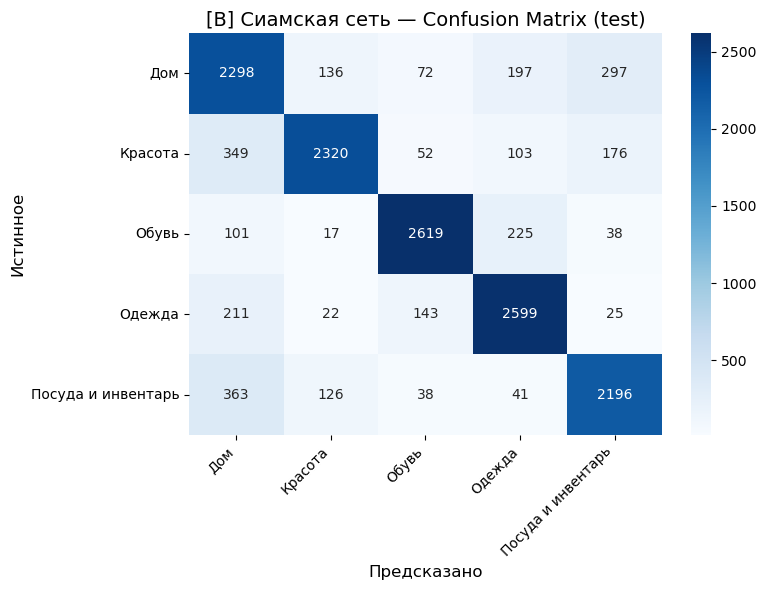

In [21]:
plot_confusion_matrix(y_test_enc, siam_test_pred, CLASS_NAMES,
                      title="[В] Сиамская сеть — Confusion Matrix (test)")

In [47]:
print("\n[В] 10 случайных примеров предсказаний (тест):")
show_random_predictions(y_test, siam_test_pred, le, texts_test, n=10)


[В] 10 случайных примеров предсказаний (тест):
#   Текст отзыва                                  Истинная кат.                Предсказание                 ✓?
---------------------------------------------------------------------------------------------------------------
1   Во время эксплуатации,насколько я аккуратно … Белье                        Аксессуары                   no
2   Маска пришла не такая как предлагает продаве… Аксессуары                   Красота                      no
3   Проносила почти все лето, очень универсальны… Обувь                        Обувь                        yes
4   Та же проблема, вместо заказанного средства,… Красота                      Красота                      yes
5   Обычно подходит 38р.р. этого производителя; … Белье                        Обувь                        no
6   У мужа ОТ 100 см, ОБ 104 см. Обычно всегда б… Белье                        Белье                        yes
7   Заказ получила! За два дня в Ростовскую обл.… Белье     

### Диалог классификации — Метод В

In [25]:
dialog_log_siam = []

print("=" * 60)
print("[В] Диалог: классификация текста (Сиамская сеть)")
print("Введите 'стоп' для выхода.")
print(f"Доступные категории: {CLASS_NAMES}")
print("=" * 60)

siamese.eval()
cat_t = torch.tensor(cat_emb_matrix, dtype=torch.float32).to(DEVICE)

while True:
    user_input = input("Текст отзыва: ").strip()
    if user_input.lower() in ('стоп', 'stop', 'quit', 'exit', ''):
        break
    emb   = model_st.encode([user_input]).astype(np.float32)
    x_t   = torch.tensor(emb, dtype=torch.float32).to(DEVICE)
    x_rep = x_t.expand(len(CLASS_NAMES), -1)
    with torch.no_grad():
        scores = torch.sigmoid(siamese(x_rep, cat_t)).cpu().numpy()
    pred_enc = int(np.argmax(scores))
    pred_lbl = CLASS_NAMES[pred_enc]
    conf     = float(scores[pred_enc])
    print(f"  → Категория: {pred_lbl}  (score: {conf:.4f})\n")
    dialog_log_siam.append({'text': user_input, 'predicted': pred_lbl, 'score': conf})

if dialog_log_siam:
    with h5py.File('dialog_siamese_rubert.h5', 'w') as f:
        dt = h5py.string_dtype(encoding='utf-8')
        f.create_dataset('texts',       data=np.asarray([d['text']      for d in dialog_log_siam], dtype=object), dtype=dt)
        f.create_dataset('predictions', data=np.asarray([d['predicted'] for d in dialog_log_siam], dtype=object), dtype=dt)
        f.create_dataset('scores',      data=np.array([d['score']       for d in dialog_log_siam]))
    print(f"Диалог сохранён: dialog_siamese_rubert.h5  ({len(dialog_log_siam)} запросов)")

[В] Диалог: классификация текста (Сиамская сеть)
Введите 'стоп' для выхода.
Доступные категории: ['Дом', 'Красота', 'Обувь', 'Одежда', 'Посуда и инвентарь']


Текст отзыва:  отличные кроссовки для бега в сеточку на высокой подошве, качеством доволен, пришли быстро, спасибо


  → Категория: Обувь  (score: 0.9990)



Текст отзыва:  для неспешных прогулок подойдут, на ногу сели хорошо качество чувствуется, швы прочные


  → Категория: Обувь  (score: 0.9987)



...

  → Категория: Посуда и инвентарь  (score: 0.8682)



Текст отзыва:  очень красивое платье до колен, приятная ткань


  → Категория: Одежда  (score: 0.9998)



Текст отзыва:  exit


Диалог сохранён: dialog_siamese_rubert.h5  (5 запросов)


### Файл 3 — Кеширование товарных эмбеддингов в пространстве Сиамской сети

Прогоняем все `prod_X` (RuBERT-векторы товаров) через `siamese.encode()`.  
Результат — новое представление товаров в метрическом пространстве, обученном на задаче сопоставления отзывов с категориями.  

**Почему это даёт другой результат, чем Файл 2:**  
Сиамский энкодер смещает и поворачивает пространство так, чтобы семантически близкие пары (отзыв ↔ категория) были ближе. Товары в этом пространстве кластеризуются иначе, чем в «сыром» RuBERT.

In [30]:
def project_through_encoder(model, X: np.ndarray, device: str, batch_size: int = 512) -> np.ndarray:
    """
    Прогоняет матрицу эмбеддингов X через siamese.encode().
    Возвращает проекцию в скрытое пространство сети.
    """
    model.eval()
    projected = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            batch = torch.tensor(X[start:start + batch_size], dtype=torch.float32).to(device)
            projected.append(model.encode(batch).cpu().numpy())
    return np.vstack(projected)


if os.path.exists(CACHE_PRODUCTS_SIAM):
    print(f"[Файл 3] Кеш найден: {CACHE_PRODUCTS_SIAM} — загружаю...")
    with h5py.File(CACHE_PRODUCTS_SIAM, 'r') as f:
        prod_X_siam = f['X'][:]  # (N_prod, hidden_dim)
    print(f"[Файл 3] Загружено: {prod_X_siam.shape}")

else:
    print(f"[Файл 3] Кеш не найден — проецирую товары через сиамский энкодер...")
    prod_X_siam = project_through_encoder(siamese, prod_X, DEVICE)
    print(f"[Файл 3] Проекция готова: {prod_X_siam.shape}")

    print(f"[Файл 3] Сохраняю в {CACHE_PRODUCTS_SIAM} ...")
    with h5py.File(CACHE_PRODUCTS_SIAM, 'w') as f:
        # Сохраняем только эмбеддинги — метаданные уже есть в Файле 2
        f.create_dataset('X', data=prod_X_siam, compression='gzip')
        # Дублируем nm_ids для удобства (можно читать Файл 3 автономно)
        f.create_dataset('nm_ids', data=prod_nm_ids)
    print(f"[Файл 3] Сохранён: {CACHE_PRODUCTS_SIAM}")

print(f"\n[Файл 3] Индекс Siamese готов: {prod_X_siam.shape}  (товаров × hidden_dim)")

[Файл 3] Кеш найден: products_siamese_rubert.h5 — загружаю...
[Файл 3] Загружено: (500000, 512)

[Файл 3] Индекс Siamese готов: (500000, 512)  (товаров × hidden_dim)


### Поиск товаров — Метод В (Сиамская сеть)

**Индекс:** `products_siamese_rubert.h5` (Файл 3) — товары в пространстве сиамского энкодера.  
**Запрос:** RuBERT → `siamese.encode()` → вектор в том же пространстве, что и товары из Файла 3.  
**Категория:** задаётся вручную (или `все`).  

Поскольку и запрос, и товары проецируются одним и тем же энкодером, косинусное расстояние отражает **метрику, обученную на задаче сопоставления**, а не просто языковую близость RuBERT.

In [31]:
search_log_siam = []
categories_str  = ', '.join(CLASS_NAMES)

print("=" * 70)
print("[В] Поиск товаров по запросу  (индекс: products_siamese_rubert.h5)")
print(f"Доступные категории: {categories_str}")
print("Введите 'стоп' в любом поле для выхода.")
print("=" * 70)

siamese.eval()

while True:
    query = input("\nЗапрос товара: ").strip()
    if query.lower() in ('стоп', 'stop', 'exit', 'quit', ''):
        break

    print(f"  Доступные категории: {categories_str}")
    print("  (или введите 'все' для поиска по всем категориям)")
    cat_input = input("  Категория: ").strip()
    if cat_input.lower() in ('стоп', 'stop', 'exit', 'quit'):
        break
    if cat_input.lower() != 'все' and cat_input not in CLASS_NAMES:
        print(f"  Категория '{cat_input}' не найдена. Доступны: {categories_str}")
        continue

    # Кодируем запрос: RuBERT → siamese.encode() → метрическое пространство
    raw_emb   = model_st.encode([query]).astype(np.float32)
    with torch.no_grad():
        t         = torch.tensor(raw_emb, dtype=torch.float32).to(DEVICE)
        query_emb = siamese.encode(t).cpu().numpy()[0]  # вектор в пространстве Файла 3

    # Поиск в Файле 3: товары уже в том же пространстве
    results, elapsed = search_products(
        query_emb, cat_input,
        prod_X_siam,  # Файл 3: Siamese-эмбеддинги товаров
        prod_nm_ids, prod_categories, prod_ratings, prod_names, prod_descs
    )
    if results.empty:
        print(f"  Нет товаров в категории '{cat_input}'.")
        continue

    print_search_results(results, elapsed, cat_input)
    search_log_siam.append({'query': query, 'category': cat_input, 'elapsed_ms': elapsed * 1000})

save_search_log(search_log_siam, 'search_log_siamese_rubert.h5')

[В] Поиск товаров по запросу  (индекс: products_siamese_rubert.h5)
Доступные категории: Дом, Красота, Обувь, Одежда, Посуда и инвентарь
Введите 'стоп' в любом поле для выхода.



Запрос товара:  кроссовки для бега в сеточку на высокой подошве качественные


  Доступные категории: Дом, Красота, Обувь, Одежда, Посуда и инвентарь
  (или введите 'все' для поиска по всем категориям)


  Категория:  Обувь



  Время поиска по эмбеддингам: 173.9 мс  |  Найдено: 10 товаров  Категория поиска: Обувь
  ──────────────────────────────────────────────────────────────────────────────────────────
   1. [6662380] Резиновые сапоги
      Рейтинг: 4.68 ★  |  Сходство: 0.2914
      Водонепроницаемая обувь.

   2. [6662391] Резиновые сапоги
      Рейтинг: 5.00 ★  |  Сходство: 0.2914
      Водонепроницаемая обувь.

   3. [6662375] Резиновые сапоги
      Рейтинг: 4.20 ★  |  Сходство: 0.2914
      Водонепроницаемая обувь.

   4. [6662363] Резиновые сапоги
      Рейтинг: 4.40 ★  |  Сходство: 0.2914
      Водонепроницаемая обувь.

   5. [6660464] Сапоги
      Рейтинг: 5.00 ★  |  Сходство: 0.2912
      Элегантные зимние сапоги Lisette на устойчивом каблуке. Модель выполнена из натурального велюра серого цвета. В области …

   6. [6660100] Сапоги
      Рейтинг: 3.00 ★  |  Сходство: 0.2895
      Элегантные зимние сапоги Westfalika на устойчивом каблуке. Модель выполнена из натурального велюра чёрного цвета. Деко

...

  Доступные категории: Дом, Красота, Обувь, Одежда, Посуда и инвентарь
  (или введите 'все' для поиска по всем категориям)


  Категория:  все



  Время поиска по эмбеддингам: 1155.1 мс  |  Найдено: 10 товаров  Категория поиска: все
  ──────────────────────────────────────────────────────────────────────────────────────────
   1. [4437440] Лоферы
      Рейтинг: 5.00 ★  |  Сходство: 0.2330
      Маломерят на один размер.

   2. [4437444] Лоферы
      Рейтинг: 5.00 ★  |  Сходство: 0.2330
      Маломерят на один размер.

   3. [1538275] Кроссовки ROYAL CLJOGG
      Рейтинг: 4.67 ★  |  Сходство: 0.2315
      Замечательные кроссовки с закругленной формой мыска. Удобная шнуровка надежно зафиксирует обувь на ногах. Рифленая подош…

   4. [8375856] Сарафан
      Рейтинг: 3.00 ★  |  Сходство: 0.2313
      сарафан отрезной по талии

   5. [7773227] Сарафан
      Рейтинг: 4.78 ★  |  Сходство: 0.2313
      сарафан отрезной по талии

   6. [7773224] Сарафан
      Рейтинг: 4.80 ★  |  Сходство: 0.2313
      сарафан отрезной по талии

   7. [7628210] Сарафан
      Рейтинг: 4.60 ★  |  Сходство: 0.2313
      сарафан отрезной по талии

   8. [13


Запрос товара:  exit


  Лог поиска сохранён: search_log_siamese_rubert.h5  (7 запросов)


---
## Итоговое сравнение методов классификации

                     Метод   F1 val  F1 test
А: Логистическая регрессия 0.857017 0.854097
          В: Сиамская сеть 0.850158 0.843973
              Б: Центроиды 0.604335 0.606680


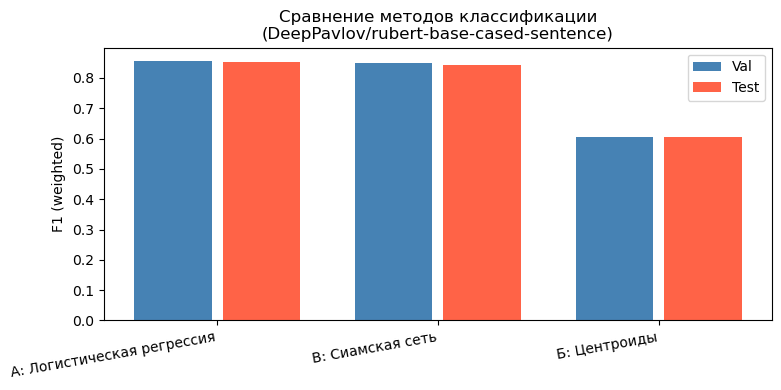

In [51]:
results_cmp = pd.DataFrame({
    'Метод':   ['А: Логистическая регрессия', 'Б: Центроиды', 'В: Сиамская сеть'],
    'F1 val':  [lr_f1_val,   cent_f1_val,  siam_f1_val],
    'F1 test': [lr_f1_test,  cent_f1_test, siam_f1_test],
})
results_cmp = results_cmp.sort_values('F1 test', ascending=False).reset_index(drop=True)
print(results_cmp.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(results_cmp))
ax.bar(x - 0.2, results_cmp['F1 val'],  0.35, label='Val',  color='steelblue')
ax.bar(x + 0.2, results_cmp['F1 test'], 0.35, label='Test', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(results_cmp['Метод'], rotation=10, ha='right')
ax.set_ylabel('F1 (weighted)')
ax.set_title('Сравнение методов классификации\n(DeepPavlov/rubert-base-cased-sentence)')
ax.legend()
plt.tight_layout()
plt.show()